#**Caso de Estudio**
Una entidad financiera (FINTECH) quiere implementar un modelo de clustering K-Means para mejorar la preaprobación de créditos de consumo de sus solicitantes de este tipo de créditos. Para este proceso vamos a utilizar las variables:

- Edad: indica el número de años que posee una persona
- Ingresos: engloba todos los ingresos que recibe una persona
- Egresoss:
- Monto (EAD):


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #Herramienta para gráfias estadísticas

from sklearn.cluster import KMeans #Herramienta de Clustering

1. Se cargan los datos de trabajo

/tmp/ipython-input-24668/3363837659.py:7: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  XDB2=XDB.ilocXD=XDB.iloc[:,[1,10,11,25,32]]


<Axes: >

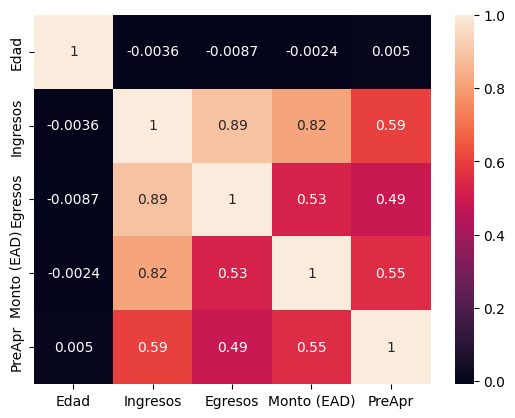

In [ ]:
nxl="/content/1. SolicitantesCrédito(USD) BASE.xlsx"
XDB=pd.read_excel(nxl,sheet_name=1) #Base AAA
XD=XDB.iloc[:,[1,10,11,25]] #Datos de entrada
yd=XDB.iloc[:,32]

#Determinamos la correlación entre las variables
XDB2=XDB.ilocXD=XDB.iloc[:,[1,10,11,25,32]]
sns.heatmap(XDB2.corr(),annot=True)


2. Se procede con la implementación del modelo KMeans

In [ ]:
np.random.seed(42) #Esto permite generar las mismas semillas para todos
NC=5 #5 segmentos o perfiles de clientes
mkm=KMeans(n_clusters=NC,random_state=42)
mkm.fit(XD,yd) #El modelo busca la mejor relación entre la entrada y la salida

#Obtenemos las características de cada grupo
Tabla=pd.DataFrame(mkm.cluster_centers_,columns=XD.columns)
display(Tabla)

#Para saber los porcentajes de PreAprobación o PreNegación por segmento, sucursal, o perfil
ydp=mkm.labels_ #Esto me indica en qué cluster queda clasificado cada dato
NDc=np.bincount(ydp) #Número de datos por segmento
print("El número de datos por cluster es:",NDc)

,Edad,Ingresos,Egresos,Monto (EAD)
0,41.062353,242.798352,213.255141,175.381339
1,40.814394,1943.037897,2034.368232,1151.374380
2,40.842975,1378.277280,825.976626,1500.438821
3,40.995816,1173.957912,1239.367737,656.163350
4,41.129177,711.127537,601.939361,537.170724


El número de datos por cluster es: [2127  264  485  960 2006]


**Análisis de resultados**

En el heatmap se puede observar que las variables que tienen una mayor correlación entre ellas son las variables de ingresos y egresos con 89%. Esto indica que su una variable aumenta su valor, la otra también se incrementa (si gano mucho, gasto mucho).
Otra correlación de relevancia es la correlación entre ingresos y monto (0.82), personas con altos ingresos, piden montos mayores (bajos ingresos-montos menores). Se destaca que la variable que tiene una mayor correlación con la variabñe PreAprobación (Salida) es la variable Ingresos (0.59).

De acuerdo con los segmentos o clusters arrojados por el modelo KMeans, podemos observar que el Cluster 1 y el Cluster 2 son los que poseen los ingresos más altos 1943 y 1378 respectivamente, clusters que igualmente son lo que tienen la menor cantidad de solicitantes de crédito con 264 y 485. Se destaca el primer Cluster, el cual agrupa a las personas con menos ingresos (242), pero es el grupo que posee la mayor cantidad de solicitantes de crédito (2127).

¿Cuál es la probabilidad de que a una persona se le apruebe un crédito de acuerdo con su cluster?

Se puede observar que el Cluster 1 y el Cluster 2, agrupan las posibilidades más altas frente a la preaprobación del crédito con un 96% y 97% de PreAprobación respectivamente. Es importante mencionar que el Cluster 0 tuvo los menores porcentajes de PreAprobación, esto promovido por los menores ingresos para las personas que hacen parte de este Cluster.

3. Porcentajes de PreAprobación

In [ ]:
XDB2["Cluster"]=ydp
display(XDB2)

#Deternminar el número de PreAprobados y PreNegados por Cluster
NApr=XDB2.groupby("Cluster").agg({"PreApr":lambda x: (x==1).sum()})
NPrn=XDB2.groupby("Cluster").agg({"PreApr":lambda x: (x==0).sum()})

#Para que la decisión sea en porcentaje
NApr2=NApr/(NApr+NPrn);NPrn2=NPrn/(NApr+NPrn)
df2=pd.DataFrame(np.column_stack((NApr2,NPrn2)),columns=["PreApr","PreNeg"])
display(df2)

/tmp/ipython-input-24668/1649229382.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  XDB2["Cluster"]=ydp


,Edad,Ingresos,Egresos,Monto (EAD),PreApr,Cluster
0,38,1356.14400,1685.622667,625.562230,1,3
1,51,286.01600,364.462000,140.031984,1,0
2,37,517.46325,629.208889,284.564492,0,4
3,29,473.27000,551.616889,309.647588,1,4
4,42,750.09175,806.715778,500.663578,1,4
...,...,...,...,...,...,...
5837,48,1207.84800,753.801111,748.041791,1,3
5838,31,1472.77200,953.812889,870.793819,1,3
5839,38,773.01975,672.910667,594.947894,1,4
5840,43,635.50175,780.691556,305.580539,1,4


,PreApr,PreNeg
0,0.137283,0.862717
1,0.962121,0.037879
2,0.973196,0.026804
3,0.772917,0.227083
4,0.559821,0.440179


4. ¿Qué pasa si aparece una nueva persona?
Edad: 30, Ingresos: 500, Egresos: 200, Monto (EAD): 150

In [ ]:
nueva_persona=np.array([30,500,200,150])
ydp=mkm.predict(nueva_persona.reshape(1,-1)) #reshape:quitarle la estructura
NCl=ydp[0] #Esto indica el cluster al que pertenece una persona
print("La persona pertenece al cluster:", ydp)
print("El porcentaje de preaprobación para la nueva persona es:",NApr2.iloc[NCl])
print("El porcentaje de prenegación para la nueva persona es:",NPrn2.iloc[NCl])

La persona pertenece al cluster: [0]
El porcentaje de preaprobación para la nueva persona es: PreApr    0.137283
Name: 0, dtype: float64
El porcentaje de prenegación para la nueva persona es: PreApr    0.862717
Name: 0, dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


5. Se procede con la gráfica de los clusters utilizando las variables Ingresos, Egresos

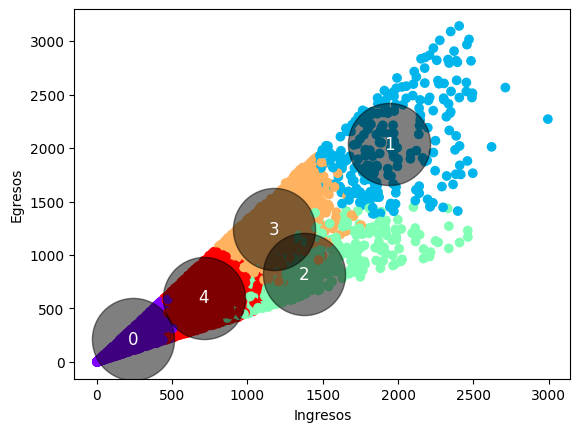

In [ ]:
centers=mkm.cluster_centers_ #Centroides, Perfil o Segmento
ing=np.array(XD.iloc[:,1]); egr=np.array(XD.iloc[:,2])

plt.figure()
plt.scatter(ing,egr,c=mkm.labels_,cmap="rainbow") #Use mkm.labels_ for all dat points
plt.scatter(centers[:,1],centers[:,2],c="black", s=3500,alpha=0.5)
plt.xlabel("Ingresos")
plt.ylabel("Egresos")


#Adicionar números a los centros
for i, center in enumerate(centers):
  plt.text(center[1], center[2], str(i), color="white", fontsize=12, ha="center", va="center")
plt.show()